---
## Imports

In [1]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import json, warnings
warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

plt.rcParams.update({"figure.dpi":150,"axes.spines.top":False,"axes.spines.right":False})

with open("outputs/eda_meta.json") as f:
    eda_meta = json.load(f)

CLASS_COUNTS   = eda_meta["class_counts"]
SYN_NEEDED     = eda_meta["synthetic_needed"]  # per-class synthetic image counts
MAJORITY_CLASS = eda_meta["majority_class"]    # nv

print("Synthetic images needed per class:")
for cls, n in SYN_NEEDED.items():
    bar = "#" * min(35, n // 100)
    skip = "(skip - already at target)" if n == 0 else ""
    print(f"  {cls:6s}: {n:5,} {bar} {skip}")
print(f"\nMajority class: {MAJORITY_CLASS} ({CLASS_COUNTS[MAJORITY_CLASS]:,} real images)")

Synthetic images needed per class:
  akiec : 6,598 ################################### 
  bcc   : 6,562 ################################### 
  bkl   : 6,383 ################################### 
  df    : 6,672 ################################### 
  mel   : 6,460 ################################### 
  nv    : 4,773 ################################### 
  vasc  : 6,664 ################################### 

Majority class: nv (1,932 real images)


---
## Shared Dataset and GAN Architecture

In [2]:
class ClassDataset(Dataset):
    '''
    Dataset for a SINGLE class -- used to train each per-class GAN.
    '''
    def __init__(self, paths, transform=None):
        self.paths     = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, 0  # label unused during GAN training


# GAN transform: resize to 64x64, normalize to [-1,1] to match Tanh output
transform_gan = transforms.Compose([
    transforms.Resize((GAN_IMG_SIZE, GAN_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),  # [0,1] -> [-1,1]
])

print("Dataset class defined ok")

Dataset class defined ok


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            self._blk(Z_DIM,        GAN_FEAT_G*8, 4, 1, 0),
            self._blk(GAN_FEAT_G*8, GAN_FEAT_G*4, 4, 2, 1),
            self._blk(GAN_FEAT_G*4, GAN_FEAT_G*2, 4, 2, 1),
            self._blk(GAN_FEAT_G*2, GAN_FEAT_G,   4, 2, 1),
            nn.ConvTranspose2d(GAN_FEAT_G, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def _blk(self, ic, oc, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(ic, oc, k, s, p, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True)
        )
    def forward(self, z): return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, GAN_FEAT_D, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True),
            self._blk(GAN_FEAT_D,   GAN_FEAT_D*2, 4, 2, 1),
            self._blk(GAN_FEAT_D*2, GAN_FEAT_D*4, 4, 2, 1),
            self._blk(GAN_FEAT_D*4, GAN_FEAT_D*8, 4, 2, 1),
            nn.Conv2d(GAN_FEAT_D*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def _blk(self, ic, oc, k, s, p):
        return nn.Sequential(
            nn.Conv2d(ic, oc, k, s, p, bias=False),
            nn.BatchNorm2d(oc), nn.LeakyReLU(0.2, True)
        )
    def forward(self, x): return self.net(x).view(-1)


def weights_init(m):
    # DCGAN paper weight init: conv~N(0,0.02), bn~N(1,0.02)
    cn = m.__class__.__name__
    if "Conv" in cn:      nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

print("Generator and Discriminator architectures defined ok")

Generator and Discriminator architectures defined ok


---
## Per-Class GAN Training Function

In [ ]:
def train_gan_for_class(cls_name, cls_paths, n_needed, show_progress=True):
    save_dir = SYNTHETIC_DIR / cls_name
    save_dir.mkdir(parents=True, exist_ok=True)

    if n_needed == 0:
        print(f"  {cls_name}: already at target, skipping GAN.")
        return []

    print(f"\n  Training GAN for class '{cls_name}' ({len(cls_paths)} real images -> {n_needed} synthetic needed)")

    # ── DataLoader ────────────────────────────────────────────────────────
    ds     = ClassDataset(cls_paths, transform=transform_gan)
    loader = DataLoader(ds, batch_size=min(16, len(ds)), shuffle=True,
                        num_workers=0, drop_last=False)

    # ── Init models ───────────────────────────────────────────────────────
    G = Generator().to(DEVICE).apply(weights_init)
    D = Discriminator().to(DEVICE).apply(weights_init)

    opt_G = optim.Adam(G.parameters(), lr=LR_GAN, betas=(BETA1_GAN, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR_GAN, betas=(BETA1_GAN, 0.999))
    criterion = nn.BCELoss()
    fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=DEVICE)

    g_losses, d_losses = [], []

    # ── Training loop ─────────────────────────────────────────────────────
    for epoch in range(1, GAN_EPOCHS + 1):
        g_ep = d_ep = 0.0
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(DEVICE)
            B = real_imgs.size(0)
            ones  = torch.ones(B,  device=DEVICE)
            zeros = torch.zeros(B, device=DEVICE)

            # Train D
            opt_D.zero_grad()
            loss_real = criterion(D(real_imgs), ones)
            z = torch.randn(B, Z_DIM, 1, 1, device=DEVICE)
            loss_fake = criterion(D(G(z).detach()), zeros)
            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward(); opt_D.step()

            # Train G
            opt_G.zero_grad()
            z = torch.randn(B, Z_DIM, 1, 1, device=DEVICE)
            loss_G = criterion(D(G(z)), ones)  # G wants D to output 1
            loss_G.backward(); opt_G.step()

            g_ep += loss_G.item(); d_ep += loss_D.item()

        g_losses.append(g_ep / len(loader))
        d_losses.append(d_ep / len(loader))

        if epoch % 50 == 0 or epoch == GAN_EPOCHS:
            eq = "ok" if abs(g_losses[-1] - 0.693) < 0.35 else "check"
            print(f"    Ep {epoch:3d}/{GAN_EPOCHS}  G:{g_losses[-1]:.3f} D:{d_losses[-1]:.3f} [{eq}]")

    # ── Save generator ────────────────────────────────────────────────────
    torch.save(G.state_dict(), MODELS_DIR / f"dcgan_G_{cls_name}.pth")

    # ── Generate n_needed images ──────────────────────────────────────────
    G.eval()
    records = []
    saved   = 0
    cls_idx = CLASS_TO_IDX[cls_name]

    with torch.no_grad():
        pbar = tqdm(total=n_needed, desc=f"    Generating {cls_name}", leave=False)
        while saved < n_needed:
            batch = min(64, n_needed - saved)
            z     = torch.randn(batch, Z_DIM, 1, 1, device=DEVICE)
            imgs  = ((G(z).cpu() + 1) / 2).clamp(0, 1)
            for img_t in imgs:
                pil  = transforms.ToPILImage()(img_t)
                path = str(save_dir / f"syn_{saved:05d}.jpg")
                pil.save(path, quality=95)
                records.append({"path": path, "label": cls_idx, "dx": cls_name})
                saved += 1
                pbar.update(1)
        pbar.close()

    print(f"    Generated {saved:,} synthetic images for '{cls_name}' -> {save_dir}")

    # ── Loss curve for this class ─────────────────────────────────────────
    return records, g_losses, d_losses

print("GAN training function defined ok")

GAN training function defined ok


---
## Load Full Dataset

In [5]:
df = pd.read_csv(META_PATH)

def find_path(image_id):
    for folder in [IMG_DIR_1, IMG_DIR_2]:
        p = folder / (image_id + ".jpg")
        if p.exists(): return str(p)
    return None

df["path"]  = df["image_id"].apply(find_path)
df["label"] = df["dx"].map(CLASS_TO_IDX)
df = df.dropna(subset=["path"])

print(f"Total real images loaded: {len(df):,}")
print("\nPer-class real image counts:")
for cls in CLASS_NAMES:
    n = len(df[df.dx==cls])
    needed = SYN_NEEDED[cls]
    print(f"  {cls:6s}: {n:5,} real, {needed:5,} synthetic needed")

Total real images loaded: 7,838

Per-class real image counts:
  akiec :   251 real, 6,598 synthetic needed
  bcc   :   391 real, 6,562 synthetic needed
  bkl   :   857 real, 6,383 synthetic needed
  df    :    92 real, 6,672 synthetic needed
  mel   :   923 real, 6,460 synthetic needed
  nv    : 5,206 real, 4,773 synthetic needed
  vasc  :   118 real, 6,664 synthetic needed


---
## Train One GAN per Class

In [6]:
all_records    = []  # all synthetic image metadata
all_g_losses   = {}  # for plotting
all_d_losses   = {}

for cls in CLASS_NAMES:
    n_needed = SYN_NEEDED[cls]

    if n_needed == 0:
        print(f"[{cls}] Already at target ({CLASS_COUNTS[cls]:,} images). Skipping.")
        continue

    cls_paths = df[df.dx == cls]["path"].tolist()

    result = train_gan_for_class(cls, cls_paths, n_needed)
    records, g_losses, d_losses = result
    all_records.extend(records)
    all_g_losses[cls] = g_losses
    all_d_losses[cls] = d_losses

print(f"\nTotal synthetic images generated: {len(all_records):,}")
print(f"Classes processed: {list(all_g_losses.keys())}")


  Training GAN for class 'akiec' (251 real images -> 6598 synthetic needed)
    Ep  50/200  G:2.634 D:0.464 [check]
    Ep 100/200  G:1.549 D:0.494 [check]
    Ep 150/200  G:2.317 D:0.496 [check]
    Ep 200/200  G:2.344 D:0.357 [check]


    Generating akiec:   0%|          | 0/6598 [00:00<?, ?it/s]

    Generated 6,598 synthetic images for 'akiec' -> outputs\synthetic_images\akiec

  Training GAN for class 'bcc' (391 real images -> 6562 synthetic needed)
    Ep  50/200  G:1.795 D:0.603 [check]
    Ep 100/200  G:1.824 D:0.596 [check]
    Ep 150/200  G:2.077 D:0.455 [check]
    Ep 200/200  G:2.737 D:0.274 [check]


    Generating bcc:   0%|          | 0/6562 [00:00<?, ?it/s]

    Generated 6,562 synthetic images for 'bcc' -> outputs\synthetic_images\bcc

  Training GAN for class 'bkl' (857 real images -> 6383 synthetic needed)
    Ep  50/200  G:1.434 D:0.609 [check]
    Ep 100/200  G:1.478 D:0.571 [check]
    Ep 150/200  G:1.936 D:0.463 [check]
    Ep 200/200  G:2.856 D:0.311 [check]


...

    Generated 6,460 synthetic images for 'mel' -> outputs\synthetic_images\mel

  Training GAN for class 'nv' (5206 real images -> 4773 synthetic needed)
    Ep  50/200  G:1.248 D:0.579 [check]
    Ep 100/200  G:3.151 D:0.255 [check]
    Ep 150/200  G:3.463 D:0.202 [check]
    Ep 200/200  G:3.398 D:0.211 [check]


    Generating nv:   0%|          | 0/4773 [00:00<?, ?it/s]

    Generated 4,773 synthetic images for 'nv' -> outputs\synthetic_images\nv

  Training GAN for class 'vasc' (118 real images -> 6664 synthetic needed)
    Ep  50/200  G:36.366 D:0.000 [check]
    Ep 100/200  G:4.929 D:0.108 [check]
    Ep 150/200  G:2.410 D:0.469 [check]
    Ep 200/200  G:2.323 D:0.599 [check]


    Generating vasc:   0%|          | 0/6664 [00:00<?, ?it/s]

    Generated 6,664 synthetic images for 'vasc' -> outputs\synthetic_images\vasc

Total synthetic images generated: 44,112
Classes processed: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


---
## Save Synthetic Metadata

In [7]:
import pandas as pd
syn_df = pd.DataFrame(all_records)
syn_df.to_csv("outputs/synthetic_meta.csv", index=False)

print("Synthetic metadata saved -> outputs/synthetic_meta.csv")
print(f"Total synthetic images: {len(syn_df):,}")
print("\nPer-class synthetic counts:")
for cls in CLASS_NAMES:
    n_syn = len(syn_df[syn_df.dx==cls]) if len(syn_df) > 0 else 0
    n_real = CLASS_COUNTS[cls]
    total  = n_real + n_syn
    print(f"  {cls:6s}: {n_real:5,} real + {n_syn:5,} synthetic = {total:5,} total")

Synthetic metadata saved -> outputs/synthetic_meta.csv
Total synthetic images: 44,112

Per-class synthetic counts:
  akiec :   107 real + 6,598 synthetic = 6,705 total
  bcc   :   143 real + 6,562 synthetic = 6,705 total
  bkl   :   322 real + 6,383 synthetic = 6,705 total
  df    :    33 real + 6,672 synthetic = 6,705 total
  mel   :   245 real + 6,460 synthetic = 6,705 total
  nv    : 1,932 real + 4,773 synthetic = 6,705 total
  vasc  :    41 real + 6,664 synthetic = 6,705 total


---
## GAN Training Loss Curves (All Classes)

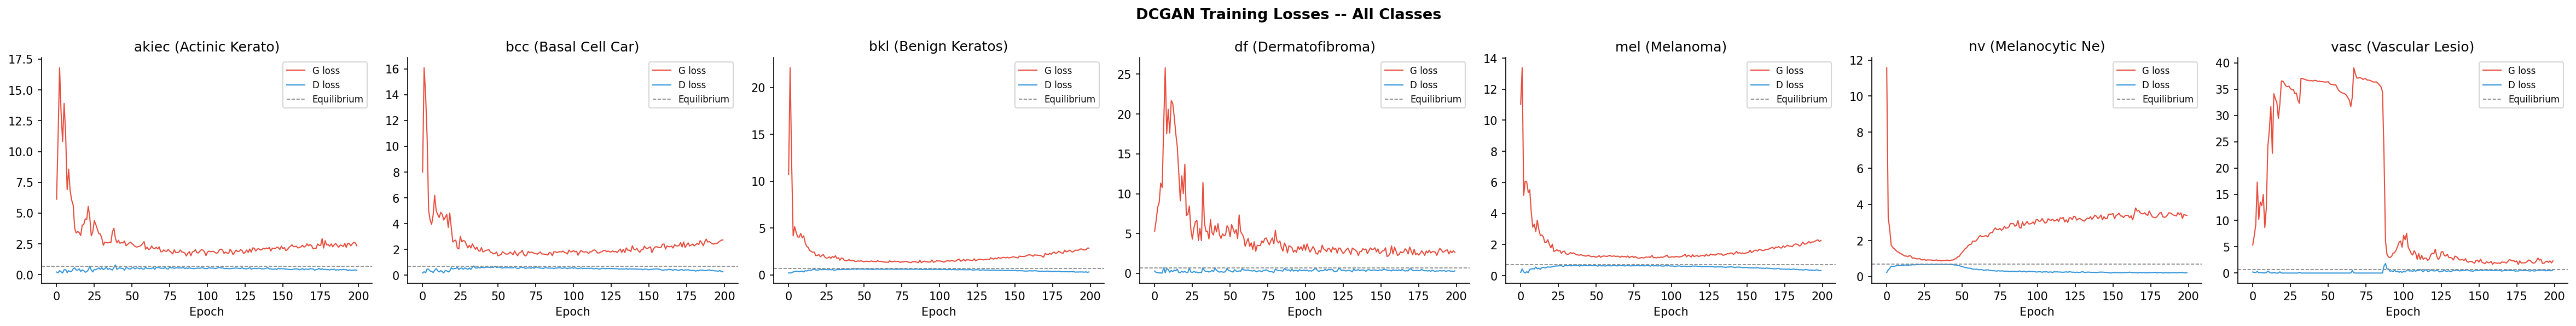

In [8]:
n_trained = len(all_g_losses)
if n_trained > 0:
    fig, axes = plt.subplots(1, n_trained, figsize=(4.5 * n_trained, 4))
    fig.suptitle("DCGAN Training Losses -- All Classes", fontsize=13, fontweight="bold")
    if n_trained == 1: axes = [axes]
    for ax, cls in zip(axes, all_g_losses.keys()):
        ax.plot(all_g_losses[cls], label="G loss", color="#e74c3c", linewidth=1)
        ax.plot(all_d_losses[cls], label="D loss", color="#3498db", linewidth=1)
        ax.axhline(0.693, color="gray", linestyle="--", linewidth=0.8, label="Equilibrium")
        ax.set_title(f"{cls} ({CLASS_FULLNAME[cls][:14]})")
        ax.set_xlabel("Epoch"); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "03_gan_losses_all.png", bbox_inches="tight")
    plt.show()

---
## Visualize Generated Images -- All Classes

Sampling from each trained generator...


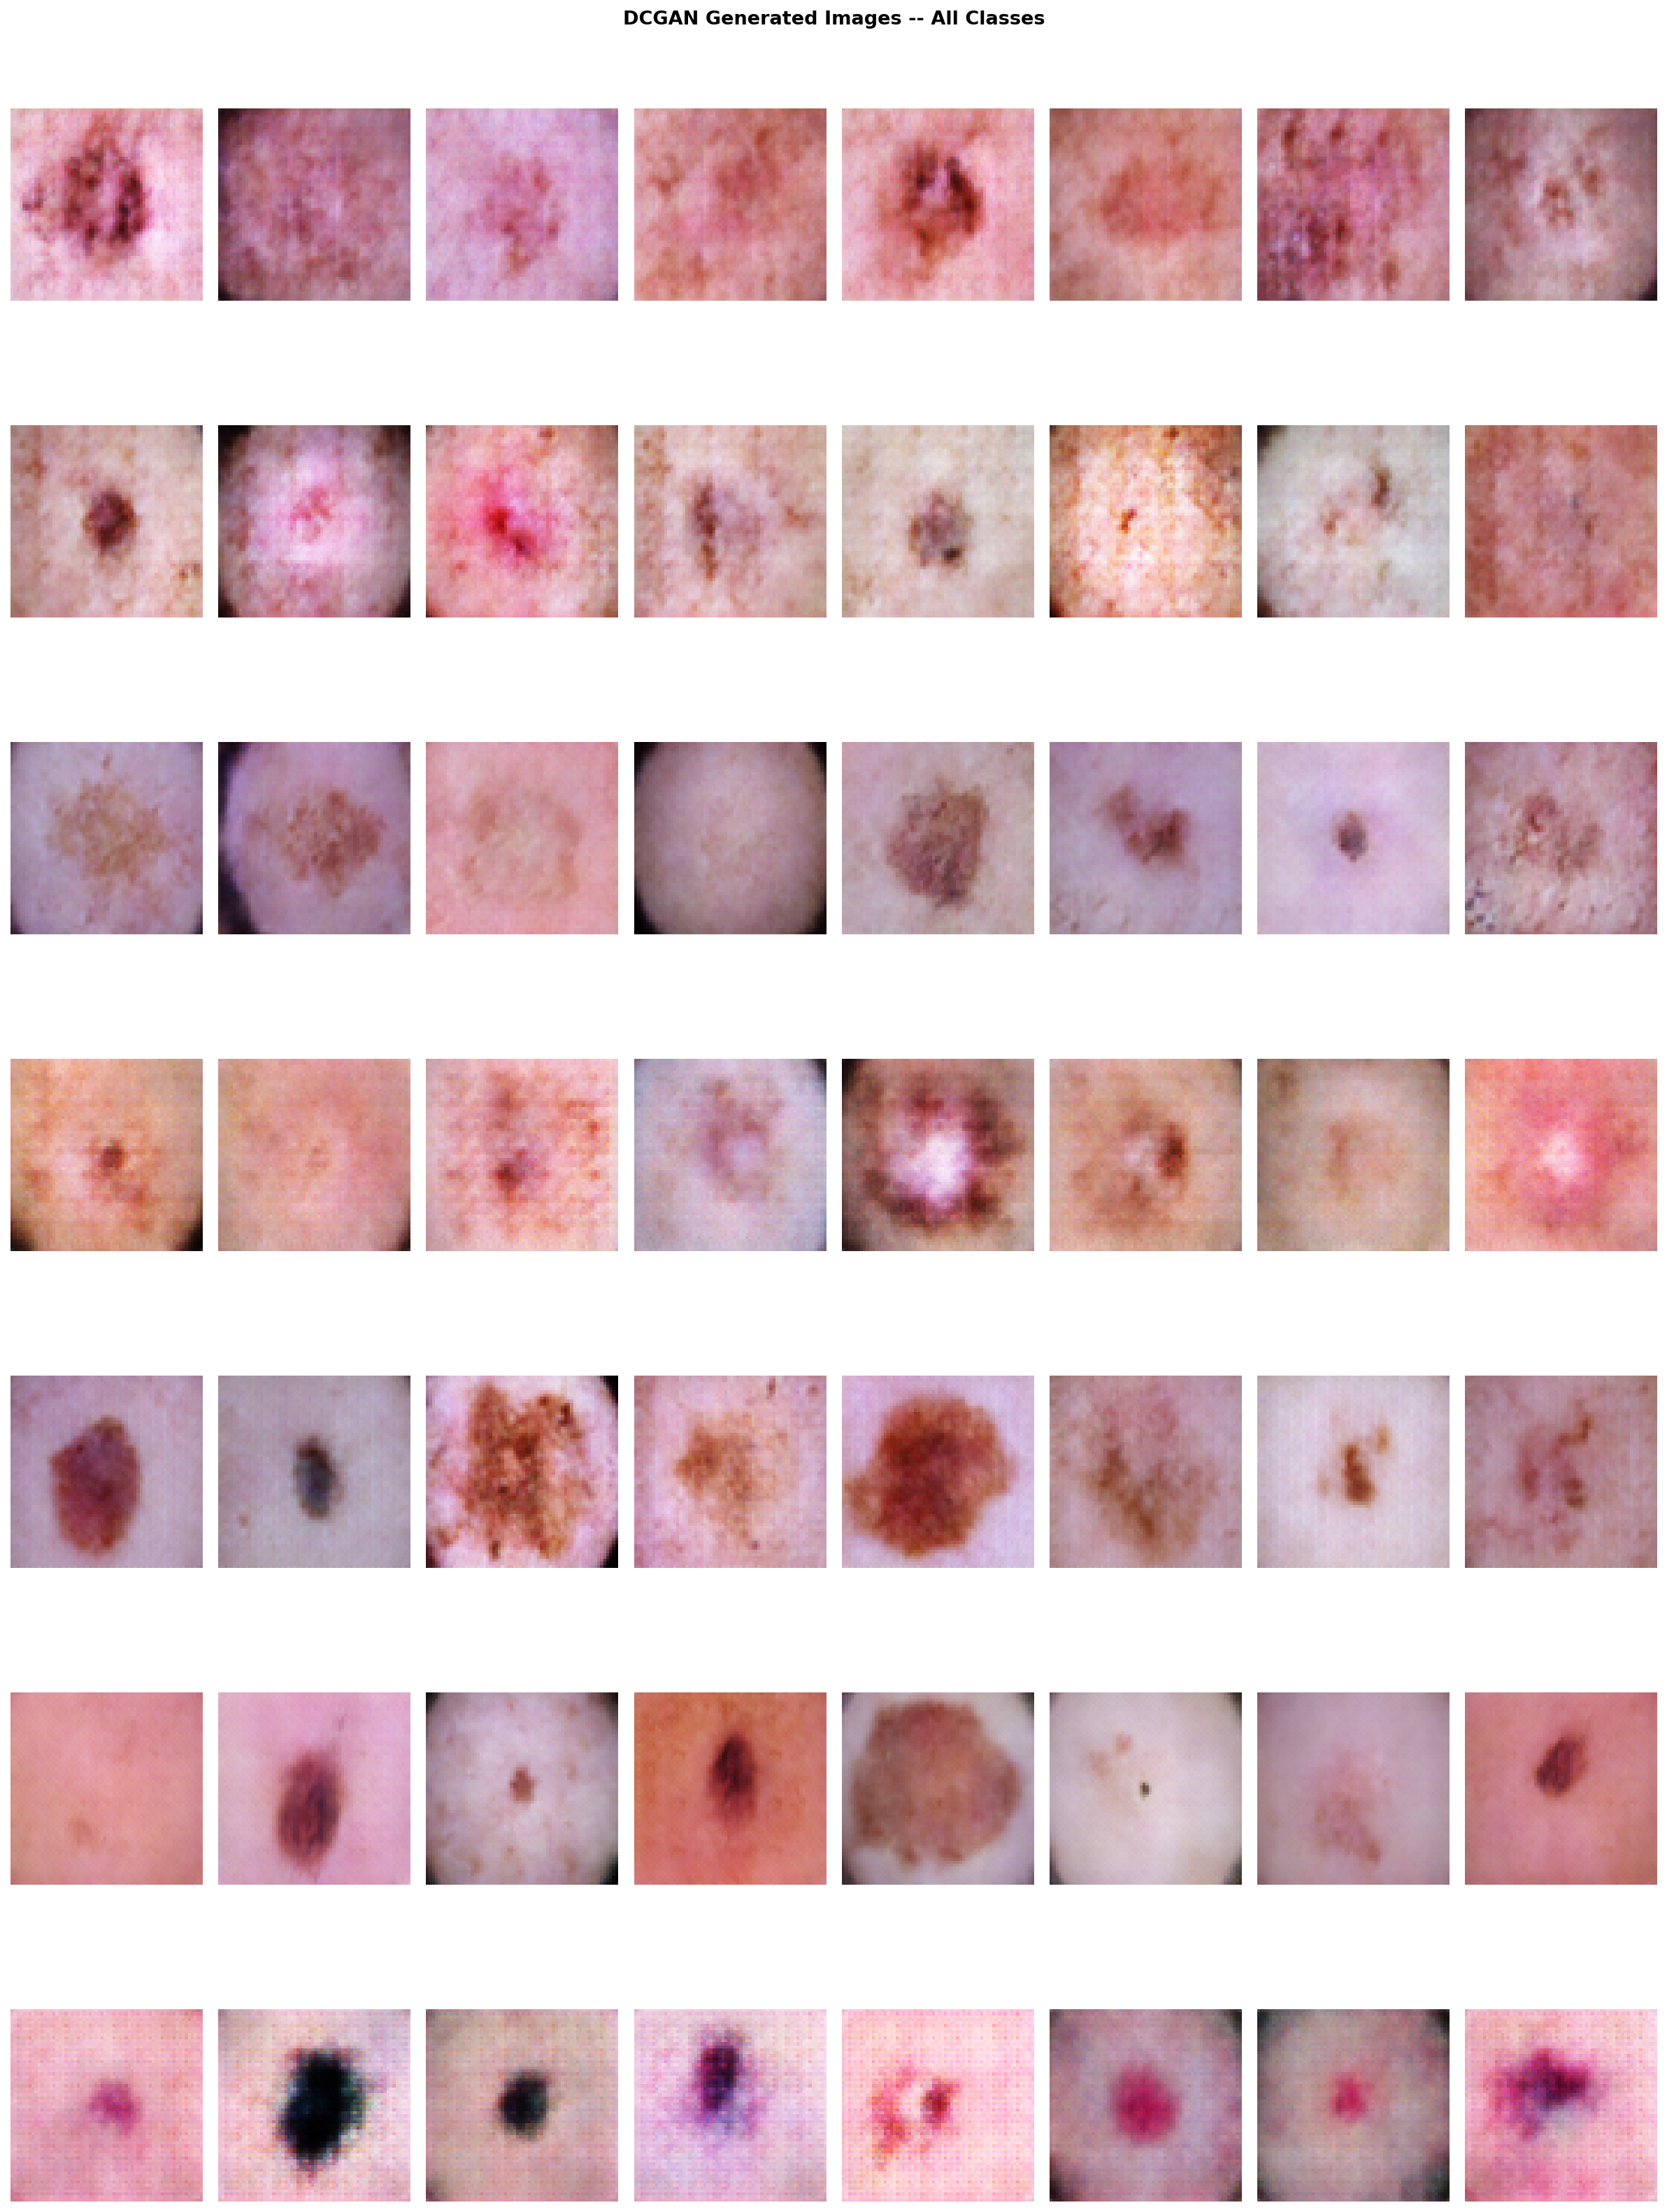


Next -> run 04_comparison.ipynb


In [9]:
print("Sampling from each trained generator...")
fig, big_axes = plt.subplots(len(all_g_losses), 8, figsize=(16, 3.2 * len(all_g_losses)))
fig.suptitle("DCGAN Generated Images -- All Classes", fontsize=13, fontweight="bold")

for row, cls in enumerate(all_g_losses.keys()):
    gen_path = MODELS_DIR / f"dcgan_G_{cls}.pth"
    G_show = Generator().to(DEVICE)
    G_show.load_state_dict(torch.load(gen_path, map_location=DEVICE))
    G_show.eval()
    with torch.no_grad():
        z    = torch.randn(8, Z_DIM, 1, 1, device=DEVICE)
        imgs = ((G_show(z).cpu() + 1) / 2).clamp(0, 1)
    axes_row = big_axes[row] if len(all_g_losses) > 1 else big_axes
    for col in range(8):
        axes_row[col].imshow(imgs[col].permute(1,2,0).numpy())
        axes_row[col].axis("off")
        if col == 0:
            axes_row[col].set_ylabel(cls, fontsize=10, rotation=0, labelpad=40)
    del G_show

plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_generated_all_classes.png", bbox_inches="tight")
plt.show()
print("\nNext -> run 04_comparison.ipynb")